In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import kagglehub

In [ ]:
# 1. Download the latest version of the dataset using kagglehub
print("Downloading dataset via kagglehub...")
path = kagglehub.dataset_download("adityarajsrv/job-descriptions-2025-tech-and-non-tech-roles")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'job-descriptions-2025-tech-and-non-tech-roles' dataset.
Path to dataset files: /kaggle/input/job-descriptions-2025-tech-and-non-tech-roles


In [ ]:
# 2. Locate and load the CSV file from the downloaded path
csv_files = glob.glob(os.path.join(path, "*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in the directory: {path}")

In [ ]:
# Load the first matching CSV
df = pd.read_csv(csv_files[0])

In [ ]:
# Set global plotting style profiles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("\n=== Dataset Structural Overview ===")
print(df.info())
print("\n--- Missing Value Audit ---")
print(df.isnull().sum())
print(f"\nTotal Dimensions - Rows: {df.shape[0]}, Columns: {df.shape[1]}")


=== Dataset Structural Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   JobID              1068 non-null   object
 1   Title              1067 non-null   object
 2   ExperienceLevel    1068 non-null   object
 3   YearsOfExperience  1068 non-null   object
 4   Skills             1068 non-null   object
 5   Responsibilities   1068 non-null   object
 6   Keywords           1068 non-null   object
dtypes: object(7)
memory usage: 58.5+ KB
None

--- Missing Value Audit ---
JobID                0
Title                1
ExperienceLevel      0
YearsOfExperience    0
Skills               0
Responsibilities     0
Keywords             0
dtype: int64

Total Dimensions - Rows: 1068, Columns: 7


--- Cleaned Experience Level Frequency Counts ---
ExperienceLevel
Experienced     476
Fresher         363
Senior-Level     81
Entry-Level      66
Mid-Level        65
Lead              7
Mid-Senior        5
Junior            5
Name: count, dtype: int64


/tmp/ipykernel_456/3971886165.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


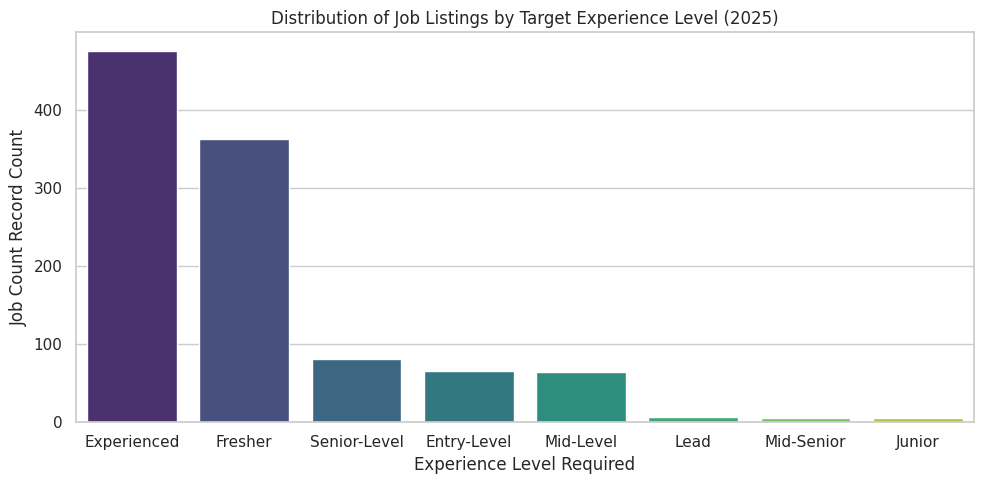

In [ ]:
# 3. Analyze Distribution of Target Experience Levels
# Strip trailing whitespaces and standardize capitalization (fixes Mid-level vs Mid-Level)
df['ExperienceLevel'] = df['ExperienceLevel'].str.strip().str.title()

# Define a explicit mapping dictionary to merge structural duplicates
category_mapping = {
    # Merging Mid-Senior variants
    'Mid-Senior Level': 'Mid-Senior',
    'Mid-Senior': 'Mid-Senior',

    # Merging Senior variants
    'Senior': 'Senior-Level',
    'Senior-Level': 'Senior-Level',
}

# Apply the mapping to merge the remaining outliers
df['ExperienceLevel'] = df['ExperienceLevel'].replace(category_mapping)

# Verify the fix
print("--- Cleaned Experience Level Frequency Counts ---")
print(df['ExperienceLevel'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='ExperienceLevel',
    order=df['ExperienceLevel'].value_counts().index,
    palette='viridis'
)
plt.title('Distribution of Job Listings by Target Experience Level (2025)')
plt.xlabel('Experience Level Required')
plt.ylabel('Job Count Record Count')
plt.tight_layout()
plt.show()

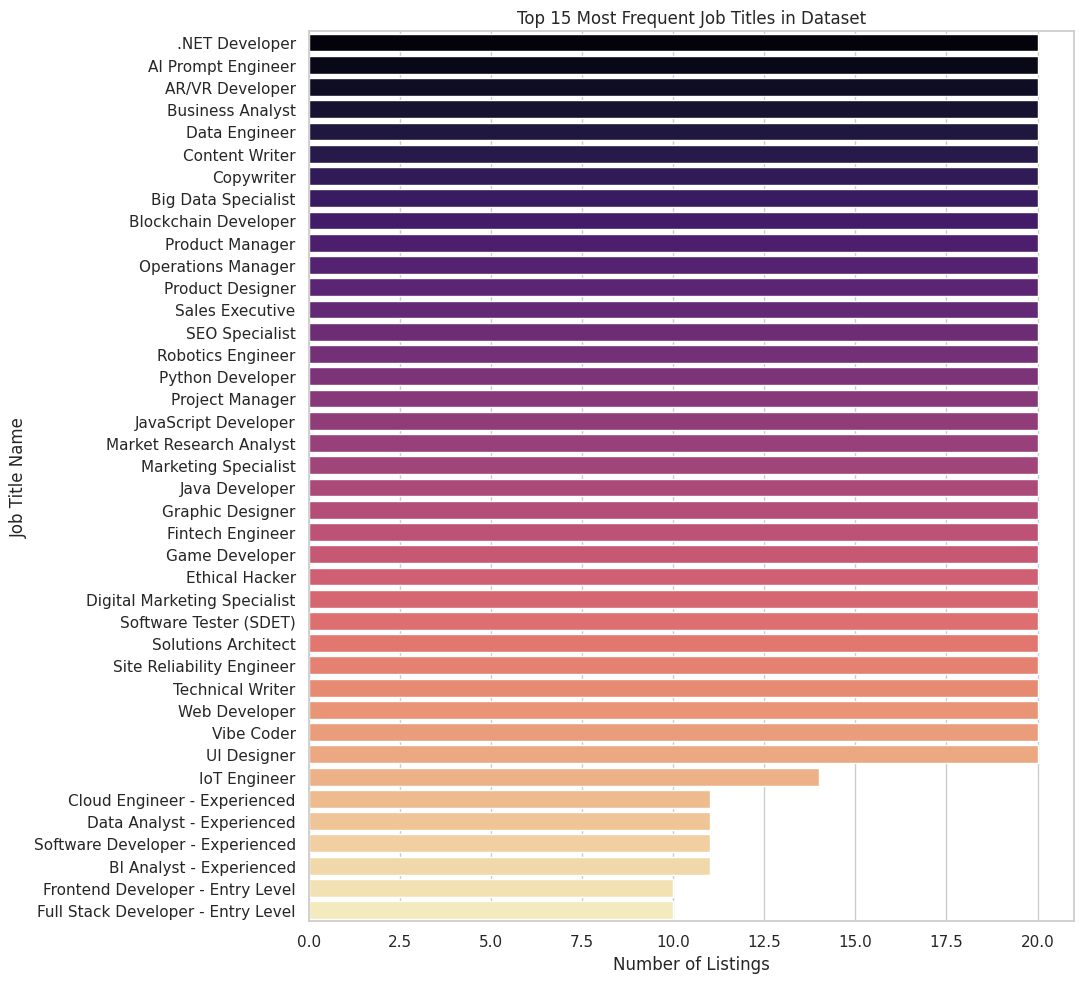

In [ ]:
# 4. Extract Top 40 Highly Represented Job Titles
plt.figure(figsize=(11, 10))
top_titles = df['Title'].value_counts().head(40)
sns.barplot(
    x=top_titles.values,
    y=top_titles.index,
    hue=top_titles.index,
    palette='magma',
    legend=False
)
plt.title('Top 15 Most Frequent Job Titles in Dataset')
plt.xlabel('Number of Listings')
plt.ylabel('Job Title Name')
plt.tight_layout()
plt.show()


Processing explicit 'Skills' column metrics...


/tmp/ipykernel_456/633237949.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tokens_df, x='Count', y=column_name, palette='coolwarm')


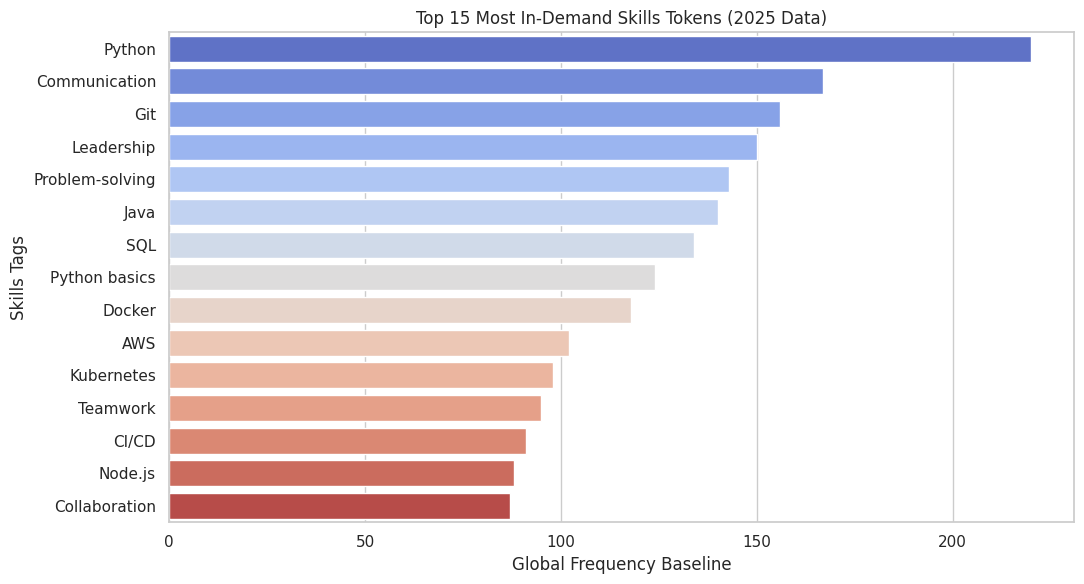


Processing industrial 'Keywords' column metrics...


/tmp/ipykernel_456/633237949.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tokens_df, x='Count', y=column_name, palette='coolwarm')


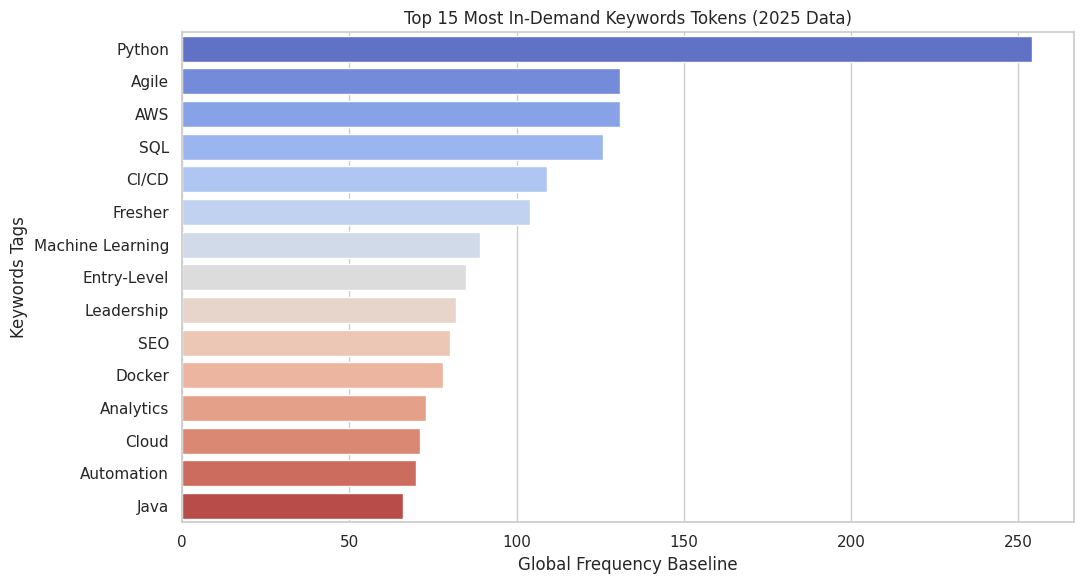


--- Cross-Tabulation Matrix: Percentage of Roles Requesting 'Python' ---
Mentions_Python       False       True 
ExperienceLevel                        
Entry-Level       31.818182   68.181818
Experienced       55.042017   44.957983
Fresher           53.719008   46.280992
Junior             0.000000  100.000000
Lead               0.000000  100.000000
Mid-Level         88.333333   11.666667
Mid-Senior         0.000000  100.000000
Mid-Senior Level  33.333333   66.666667
Mid-level          0.000000  100.000000
Senior             0.000000  100.000000
Senior-Level      27.272727   72.727273


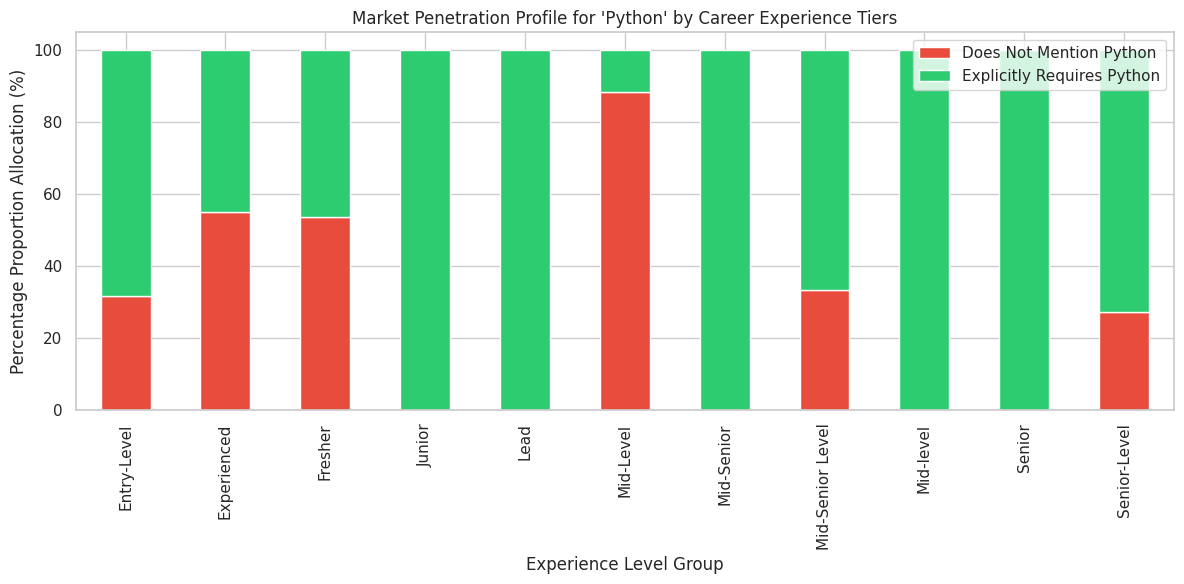

In [ ]:
# 6. Cross-Tabulation Analysis: Target Skills Across Career Experience Paths
def check_skill_trajectory(dataframe, targeted_skill):
    """
    Evaluates the exact percentage requirement changes of a specified technical skill
    stratified across the dataset's experience categories.
    """
    # Safe regex containment search for structural skills text array parsing
    dataframe[f'Mentions_{targeted_skill}'] = dataframe['Skills'].astype(str).apply(
        lambda x: targeted_skill.lower() in x.lower()
    )

    # Cross tabulate normalized percentage allocations
    matrix = pd.crosstab(dataframe['ExperienceLevel'], dataframe[f'Mentions_{targeted_skill}'], normalize='index') * 100
    print(f"\n--- Cross-Tabulation Matrix: Percentage of Roles Requesting '{targeted_skill}' ---")
    print(matrix)

    matrix.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'])
    plt.title(f"Market Penetration Profile for '{targeted_skill}' by Career Experience Tiers")
    plt.ylabel('Percentage Proportion Allocation (%)')
    plt.xlabel('Experience Level Group')
    plt.legend([f'Does Not Mention {targeted_skill}', f'Explicitly Requires {targeted_skill}'])
    plt.tight_layout()
    plt.show()

    # Run stratified test check for Python demands across Tech vs Non-tech background segments
check_skill_trajectory(df, 'Python')